In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ai_impact_jobs_2010_2025.csv")
data.head()

,job_id,posting_year,country,region,city,company_name,company_size,industry,job_title,seniority_level,...,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage
0,836b4774-702e-49ef-93d3-2f255ce1e910,2018,Brazil,South America,London,NextGen Technologies,Small,Education,Policy Analyst,Lead,...,0.81,"Research, Project Management, Business Analysis",reinforcement learning,61586,12.68,0.11,True,Low,14,Growing
1,43699e93-7b15-4728-a4c6-9e41ff438a25,2015,UAE,Middle East,Singapore,Future Solutions,Medium,Energy,Data Scientist,Executive,...,0.04,"Research, SQL, Business Analysis, Python, Clou...",NaN,62045,-3.98,0.71,False,High,19,Emerging
2,fc9d1854-3cbf-4bab-90df-77304dfc59df,2016,Nepal,South Asia,Sydney,Future Analytics,Startup,Finance,Product Manager,Junior,...,0.15,"Statistics, Project Management, Cloud Computin...",NaN,27035,3.55,0.86,False,High,2,Emerging
3,05c1c7d3-2add-4919-91eb-f6c78bfe23d1,2015,Spain,Europe,Nairobi,Global Technologies,Large,Government,Data Scientist,Mid,...,0.19,"Cloud Computing, SQL, Project Management, Comm...",NaN,72894,-2.80,0.70,False,Low,15,Emerging
4,5e739937-d1b0-44d7-935c-7ebb3fc1f6e8,2014,Taiwan,East Asia,Sydney,Future Technologies,Small,Manufacturing,ML Engineer,Lead,...,0.11,"SQL, Python, Communication, Software Engineeri...",NaN,57215,0.85,0.87,False,High,13,Emerging


1. Data Cleaning

In [3]:
# Detect missing values
missing_data = data.isnull().sum()
print(missing_data[missing_data>0])

ai_keywords    3377
ai_skills      3377
dtype: int64


In [4]:
missing_values = ""
na_values = missing_values

data[["ai_keywords", "ai_skills"]]

,ai_keywords,ai_skills
0,reinforcement learning,reinforcement learning
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
4995,NaN,NaN
4996,NaN,NaN
4997,NaN,NaN
4998,"computer vision, MLOps","computer vision, MLOps"


In [5]:
# Handle missing values
data["ai_keywords"] = data["ai_keywords"].fillna("Not Specified")
data["ai_skills"] = data["ai_skills"].fillna("None")
data[["ai_keywords", "ai_skills"]]

# Recheck missing values
data.isnull().sum()

,0
job_id,0
posting_year,0
country,0
region,0
city,0
company_name,0
company_size,0
industry,0
job_title,0
seniority_level,0


2. Data Preprocessing

In [6]:
# Create time feature
data["year_index"] = data["posting_year"] - data["posting_year"].min()

In [7]:
# Type conversion
data["ai_mentioned"] = data["ai_mentioned"].astype(int)
data["reskilling_required"] = data["reskilling_required"].astype(int)

print(data[["ai_mentioned", "reskilling_required"]].dtypes)

ai_mentioned           int64
reskilling_required    int64
dtype: object


In [8]:
# One Hot Encoding
data = pd.get_dummies(data, columns = ["industry", "company_size", "country", "region"], drop_first = True)

In [9]:
# Lable Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data["seniority_level"] = le.fit_transform(data["seniority_level"])
data["ai_job_displacement_risk"] = le.fit_transform(data["ai_job_displacement_risk"])
data["industry_ai_adoption_stage"] = le.fit_transform(data["industry_ai_adoption_stage"])

In [10]:
# Extract Feature
data["core_skill_count"] = data["core_skills"].apply(lambda x: len(str(x).split(",")))
data["ai_skill_count"] = data["ai_skills"].apply(lambda x: len(str(x).split(",")))
data["total_skill_count"] = data["core_skill_count"] + data["ai_skill_count"]

In [11]:
# Binary Skill Indicators
data["has_python"] = data["core_skills"].apply(lambda x: 1 if "Python" in str(x) else 0)
data["has_sql"] = data["core_skills"].apply(lambda x: 1 if "SQL" in str(x) else 0)
data["has_cloud_computing"] = data["core_skills"].apply(lambda x: 1 if "Cloud Computing" in str(x) else 0)
data["has_software_engineering"] = data["core_skills"].apply(lambda x: 1 if "Software Engineering" in str(x) else 0)
data["has_data_analysis"] = data["core_skills"].apply(lambda x: 1 if "Data Analysis" in str(x) else 0)
data["has_project_management"] = data["core_skills"].apply(lambda x: 1 if "Project Management" in str(x) else 0)
data["has_machine_learning"] = data["ai_skills"].apply(lambda x: 1 if "Machine Learning" in str(x) else 0)
data["has_deep_learning"] = data["ai_skills"].apply(lambda x: 1 if "Deep Learning" in str(x) else 0)
data["has_computer_vision"] = data["ai_skills"].apply(lambda x: 1 if "Computer Vision" in str(x) else 0)
data["has_nlp"] = data["ai_skills"].apply(lambda x: 1 if "NLP" in str(x) else 0)

In [12]:
# Skill ratio feature
data["ai_skill_ratio"] = data["ai_skill_count"] / (data["total_skill_count"] + 1)

In [13]:
data[["core_skills", "ai_skills", "core_skill_count", "ai_skill_count", "total_skill_count"]].head()

,core_skills,ai_skills,core_skill_count,ai_skill_count,total_skill_count
0,"Research, Project Management, Business Analysis",reinforcement learning,3,1,4
1,"Research, SQL, Business Analysis, Python, Clou...",None,6,1,7
2,"Statistics, Project Management, Cloud Computin...",None,5,1,6
3,"Cloud Computing, SQL, Project Management, Comm...",None,6,1,7
4,"SQL, Python, Communication, Software Engineeri...",None,6,1,7


In [14]:
# Derive features
data["high_automation_risk"] = data["automation_risk_score"].apply(lambda x: 1 if x > 0.7 else 0)

In [15]:
# Composite index
data["ai_impact_index"] = (
    data["ai_intensity_score"] + data["automation_risk_score"]
) / 2

In [16]:
data[["ai_skills", "ai_skill_count", "total_skill_count", "ai_skill_ratio"]].head()

,ai_skills,ai_skill_count,total_skill_count,ai_skill_ratio
0,reinforcement learning,1,4,0.200000
1,None,1,7,0.125000
2,None,1,6,0.142857
3,None,1,7,0.125000
4,None,1,7,0.125000


3. Predictions

3.1 AI Skill Demand Ratio

3.1.1 Train the data and use Linear Regression model for analysis

In [17]:
data["core_skill_count"] = data["core_skills"].apply(lambda x: len(str(x).split(",")))
data["ai_skill_count"] = data["ai_skills"].apply(lambda x: len(str(x).split(",")))

In [18]:
data["total_skill_count"] = data["core_skill_count"] + data["ai_skill_count"]

In [19]:
data["ai_skill_ratio"] = data["ai_skill_count"] / (data["total_skill_count"] + 1)

In [20]:
job_count_by_year = data.groupby("posting_year").size().reset_index(name="job_count")

In [21]:
data = data.merge(job_count_by_year, on="posting_year", how="left")
data.head()

,job_id,posting_year,city,company_name,job_title,seniority_level,ai_mentioned,ai_keywords,ai_intensity_score,core_skills,...,has_data_analysis,has_project_management,has_machine_learning,has_deep_learning,has_computer_vision,has_nlp,ai_skill_ratio,high_automation_risk,ai_impact_index,job_count
0,836b4774-702e-49ef-93d3-2f255ce1e910,2018,London,NextGen Technologies,Policy Analyst,3,1,reinforcement learning,0.81,"Research, Project Management, Business Analysis",...,0,1,0,0,0,0,0.200000,0,0.460,282
1,43699e93-7b15-4728-a4c6-9e41ff438a25,2015,Singapore,Future Solutions,Data Scientist,0,0,Not Specified,0.04,"Research, SQL, Business Analysis, Python, Clou...",...,1,0,0,0,0,0,0.125000,1,0.375,312
2,fc9d1854-3cbf-4bab-90df-77304dfc59df,2016,Sydney,Future Analytics,Product Manager,2,0,Not Specified,0.15,"Statistics, Project Management, Cloud Computin...",...,0,1,0,0,0,0,0.142857,1,0.505,311
3,05c1c7d3-2add-4919-91eb-f6c78bfe23d1,2015,Nairobi,Global Technologies,Data Scientist,4,0,Not Specified,0.19,"Cloud Computing, SQL, Project Management, Comm...",...,1,1,0,0,0,0,0.125000,0,0.445,312
4,5e739937-d1b0-44d7-935c-7ebb3fc1f6e8,2014,Sydney,Future Technologies,ML Engineer,3,0,Not Specified,0.11,"SQL, Python, Communication, Software Engineeri...",...,0,0,0,0,0,0,0.125000,1,0.490,316


In [22]:
trend_data = data.groupby("posting_year").agg({
    "job_count": "first",
    "ai_skill_count": "mean",
    "total_skill_count": "mean",
    "ai_skill_ratio": "mean"
}).reset_index()

trend_data

,posting_year,job_count,ai_skill_count,total_skill_count,ai_skill_ratio
0,2010,327,1.155963,5.724771,0.171951
1,2011,294,1.108844,5.612245,0.168531
2,2012,310,1.106452,5.661290,0.167859
3,2013,326,1.150307,5.625767,0.173090
4,2014,316,1.325949,5.813291,0.190711
5,2015,312,1.266026,5.858974,0.181996
6,2016,311,1.215434,5.672026,0.180662
7,2017,305,1.295082,5.665574,0.190168
8,2018,282,1.578014,6.106383,0.214963
9,2019,331,1.519637,6.105740,0.207066


In [23]:
X = trend_data[["posting_year", "total_skill_count", "ai_skill_count", "job_count"]]
y = trend_data["ai_skill_ratio"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [26]:
lr_pred = lr_model.predict(X_test)

print("Linear Regression MSE:", mean_squared_error(y_test, lr_pred))
print("Linear Regression R2:", r2_score(y_test, lr_pred))

Linear Regression MSE: 2.031313312310312e-06
Linear Regression R2: 0.9984676488040247


In [27]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest MSE:", mean_squared_error(y_test, rf_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))

Random Forest MSE: 4.985378979782256e-05
Random Forest R2: 0.9623920574154516


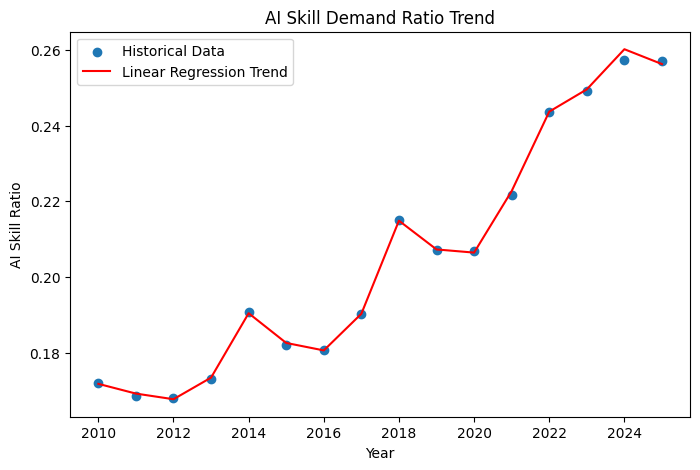

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(trend_data["posting_year"], trend_data["ai_skill_ratio"], label="Historical Data")
plt.plot(trend_data["posting_year"], lr_model.predict(X), color="red", label="Linear Regression Trend")
plt.xlabel("Year")
plt.ylabel("AI Skill Ratio")
plt.title("AI Skill Demand Ratio Trend")
plt.legend()
plt.show()

3.1.2 Predicting future AI skill demand ratio

In [29]:
X_year = trend_data[["posting_year"]]

total_skill_model = LinearRegression()
total_skill_model.fit(X_year, trend_data["total_skill_count"])

ai_skill_model = LinearRegression()
ai_skill_model.fit(X_year, trend_data["ai_skill_count"])

job_count_model = LinearRegression()
job_count_model.fit(X_year, trend_data["job_count"])

LinearRegression()

In [30]:
future_years = pd.DataFrame({
    "posting_year": [2026, 2027, 2028, 2029, 2030]
})

future_years["total_skill_count"] = total_skill_model.predict(future_years[["posting_year"]])
future_years["ai_skill_count"] = ai_skill_model.predict(future_years[["posting_year"]])
future_years["job_count"] = job_count_model.predict(future_years[["posting_year"]])

In [31]:
future_years["predicted_ai_skill_ratio"] = lr_model.predict(
    future_years[["posting_year", "total_skill_count", "ai_skill_count", "job_count"]]
)
future_years.head()

,posting_year,total_skill_count,ai_skill_count,job_count,predicted_ai_skill_ratio
0,2026,6.545034,2.045612,314.925000,0.260854
1,2027,6.610248,2.111916,315.210294,0.267377
2,2028,6.675462,2.178220,315.495588,0.273901
3,2029,6.740676,2.244524,315.780882,0.280424
4,2030,6.805890,2.310829,316.066176,0.286947


In [ ]:
import joblib

joblib.dump(lr_model, "ai_skill_model.pkl")

['ai_skill_model.pkl']

In [ ]:
from google.colab import files

files.download("ai_skill_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

3.2 Future Job Prediction




In [32]:
job_demand = data["job_title"].value_counts().reset_index()

job_demand.columns = ["job_title", "job_count"]

print(job_demand.head())

            job_title  job_count
0         ML Engineer        558
1  Operations Manager        525
2  Research Scientist        520
3       AI Researcher        512
4    Systems Engineer        505


In [33]:
top_jobs = job_demand.head(10)

print(top_jobs)

            job_title  job_count
0         ML Engineer        558
1  Operations Manager        525
2  Research Scientist        520
3       AI Researcher        512
4    Systems Engineer        505
5   Software Engineer        492
6      Data Scientist        486
7      Policy Analyst        482
8    Business Analyst        480
9     Product Manager        440


In [34]:
job_trend = data.groupby(["posting_year", "job_title"]).size().reset_index(name="job_count")

print(job_trend.head())

   posting_year           job_title  job_count
0          2010       AI Researcher         35
1          2010    Business Analyst         29
2          2010      Data Scientist         29
3          2010         ML Engineer         45
4          2010  Operations Manager         29


In [35]:
from sklearn.linear_model import LinearRegression

job_predictions = {}

for job in job_trend["job_title"].unique():

    job_data = job_trend[job_trend["job_title"] == job]

    X = job_data[["posting_year"]]
    y = job_data["job_count"]

    model = LinearRegression()
    model.fit(X, y)

    future_years = [[2026], [2027], [2028], [2029], [2030]]

    predictions = model.predict(future_years)

    job_predictions[job] = predictions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

In [36]:
future_years = [2026, 2027, 2028, 2029, 2030]

results = []

for job, preds in job_predictions.items():

    for year, value in zip(future_years, preds):

        results.append({
            "job_title": job,
            "year": year,
            "predicted_job_count": value
        })

predicted_jobs = pd.DataFrame(results)

print(predicted_jobs.head())

       job_title  year  predicted_job_count
0  AI Researcher  2026            33.875000
1  AI Researcher  2027            34.095588
2  AI Researcher  2028            34.316176
3  AI Researcher  2029            34.536765
4  AI Researcher  2030            34.757353


In [37]:
top_jobs_by_year = predicted_jobs.sort_values(
    ["year", "predicted_job_count"],
    ascending=[True, False]
)

top_jobs_by_year = top_jobs_by_year.groupby("year").head(5)

print(top_jobs_by_year)

             job_title  year  predicted_job_count
15         ML Engineer  2026            34.800000
20  Operations Manager  2026            34.625000
0        AI Researcher  2026            33.875000
5     Business Analyst  2026            32.825000
45    Systems Engineer  2026            32.375000
21  Operations Manager  2027            34.838235
16         ML Engineer  2027            34.791176
1        AI Researcher  2027            34.095588
6     Business Analyst  2027            33.157353
46    Systems Engineer  2027            32.470588
22  Operations Manager  2028            35.051471
17         ML Engineer  2028            34.782353
2        AI Researcher  2028            34.316176
7     Business Analyst  2028            33.489706
47    Systems Engineer  2028            32.566176
23  Operations Manager  2029            35.264706
18         ML Engineer  2029            34.773529
3        AI Researcher  2029            34.536765
8     Business Analyst  2029            33.822059


In [38]:
top_jobs_by_year.to_csv("future_job_predictions.csv", index=False)

In [39]:
from google.colab import files
files.download("future_job_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

3.3 Top Skills Prediction


In [40]:
data["all_skills"] = data["core_skills"].astype(str) + "," + data["ai_skills"].astype(str)

In [41]:
skills_df = data.assign(skill=data["all_skills"].str.split(",")).explode("skill")

In [42]:
skills_df["skill"] = skills_df["skill"].str.strip()

In [43]:
skill_trend = skills_df.groupby(["posting_year", "skill"]).size().reset_index(name="skill_count")

print(skill_trend.head())

   posting_year              skill  skill_count
0          2010  Business Analysis          149
1          2010    Cloud Computing          143
2          2010      Communication          156
3          2010      Data Analysis          146
4          2010              MLOps           13


In [44]:
from sklearn.linear_model import LinearRegression

skill_predictions = {}

for skill in skill_trend["skill"].unique():

    skill_data = skill_trend[skill_trend["skill"] == skill]

    X = skill_data[["posting_year"]]
    y = skill_data["skill_count"]

    model = LinearRegression()
    model.fit(X, y)

    future_years = [[2026], [2027], [2028], [2029], [2030]]

    predictions = model.predict(future_years)

    skill_predictions[skill] = predictions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

In [45]:
future_years = [2026, 2027, 2028, 2029, 2030]

results = []

for skill, preds in skill_predictions.items():

    for year, value in zip(future_years, preds):

        results.append({
            "skill": skill,
            "year": year,
            "predicted_skill_demand": value
        })

predicted_skills = pd.DataFrame(results)

In [46]:
top_skills = predicted_skills.sort_values(
    ["year", "predicted_skill_demand"],
    ascending=[True, False]
)

top_skills = top_skills.groupby("year").head(5)

print(top_skills)

                   skill  year  predicted_skill_demand
0      Business Analysis  2026              153.050000
50                   SQL  2026              143.550000
35    Project Management  2026              142.525000
40                Python  2026              142.175000
55  Software Engineering  2026              141.600000
1      Business Analysis  2027              153.879412
51                   SQL  2027              143.592647
36    Project Management  2027              142.917647
41                Python  2027              142.173529
56  Software Engineering  2027              141.552941
2      Business Analysis  2028              154.708824
52                   SQL  2028              143.635294
37    Project Management  2028              143.310294
42                Python  2028              142.172059
17         Data Analysis  2028              141.580882
3      Business Analysis  2029              155.538235
38    Project Management  2029              143.702941
53        

In [ ]:
top_skills.to_csv("future_skill_predictions.csv", index=False)

In [ ]:
from google.colab import files
files.download("future_skill_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

3.4 AI Automation Risk Prediction

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data["risk_encoded"] = le.fit_transform(data["ai_job_displacement_risk"])

In [48]:
print(data[["ai_job_displacement_risk","risk_encoded"]].head())

   ai_job_displacement_risk  risk_encoded
0                         1             1
1                         0             0
2                         0             0
3                         1             1
4                         0             0


In [49]:
future_years = [2026, 2027, 2028, 2029, 2030]

In [50]:
from sklearn.ensemble import RandomForestClassifier

results = []

for job in data["job_title"].unique():

    job_data = data[data["job_title"] == job]

    X = job_data[["posting_year","ai_skill_count","total_skill_count"]]
    y = job_data["risk_encoded"]

    model = RandomForestClassifier()
    model.fit(X,y)

    for year in future_years:
      for job in data["job_title"].unique():

        job_factor = np.random.uniform(0.8, 1.2)
        ai_skill = (1 + (year - 2010) * 0.35) * job_factor
        total_skill = (5 + (year - 2010) * 0.5) * job_factor

        pred = model.predict([[year, ai_skill, total_skill]])[0]

        results.append({
            "posting_year": year,
            "job_title": job,
            "predicted_risk": pred
        })

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

In [51]:
future_risk = pd.DataFrame(results)

future_risk.head()

,posting_year,job_title,predicted_risk
0,2026,Policy Analyst,0
1,2026,Data Scientist,0
2,2026,Product Manager,0
3,2026,ML Engineer,0
4,2026,Software Engineer,0


In [52]:
future_risk["predicted_risk"] = le.inverse_transform(
    future_risk["predicted_risk"]
)

future_risk.head()

,posting_year,job_title,predicted_risk
0,2026,Policy Analyst,0
1,2026,Data Scientist,0
2,2026,Product Manager,0
3,2026,ML Engineer,0
4,2026,Software Engineer,0


In [ ]:
future_risk.to_csv("future_automation_risk.csv", index=False)

In [ ]:
from google.colab import files
files.download("future_automation_risk.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

4.1 Updated preprocessed datast for AI Automation Risk Prediction

In [53]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/future_automation_risk.csv")

In [54]:
df = df.drop_duplicates(subset=["posting_year", "job_title"]).copy()

In [55]:
base_map = {
    "Low": 35,
    "Medium": 65,
    "High": 80
}

df["base_percentage"] = df["predicted_risk"].map(base_map)

In [56]:
df["year_effect"] = (df["posting_year"] - 2026) * 3

In [57]:
np.random.seed(42)
df["job_variation"] = np.random.uniform(-4, 4, len(df))

In [58]:
df["risk_percentage"] = (
    df["base_percentage"] +
    df["year_effect"] +
    df["job_variation"]
).clip(0, 100)

In [59]:
df["rank"] = df.groupby("posting_year")["risk_percentage"] \
               .rank(method="first", ascending=False)

In [60]:
df = df.sort_values(["posting_year", "rank"])

df[df["posting_year"] == 2026][
    ["job_title", "predicted_risk", "risk_percentage", "rank"]
].head(10)

,job_title,predicted_risk,risk_percentage,rank
1,Data Scientist,High,83.605714,1.0
7,Operations Manager,High,82.929409,2.0
2,Product Manager,High,81.855952,3.0
9,Business Analyst,High,81.664581,4.0
8,Research Scientist,High,80.808920,5.0
3,ML Engineer,High,80.789268,6.0
0,Policy Analyst,High,78.996321,7.0
4,Software Engineer,High,77.248149,8.0
5,Systems Engineer,High,77.247956,9.0
6,AI Researcher,High,76.464669,10.0


In [61]:
df[df["posting_year"] == 2029][
    ["job_title", "predicted_risk", "risk_percentage", "rank"]
].head(10)

,job_title,predicted_risk,risk_percentage,rank
34,Software Engineer,High,92.725056,1.0
33,ML Engineer,High,92.591084,2.0
35,Systems Engineer,High,91.467179,3.0
38,Research Scientist,High,90.473864,4.0
30,Policy Analyst,High,89.860359,5.0
39,Business Analyst,High,88.521220,6.0
36,AI Researcher,High,87.436910,7.0
31,Data Scientist,High,86.364193,8.0
37,Operations Manager,High,85.781377,9.0
32,Product Manager,High,85.520413,10.0


In [ ]:
df.to_csv("future_automation_risk_updated.csv", index=False)

In [ ]:
from google.colab import files
files.download("future_automation_risk_updated.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>